# segger quickstart

Segger is a graph neural network for cell segmentation in imaging-based spatial transcriptomics data (Xenium, MERSCOPE, CosMx). It builds a transcript-transcript proximity graph, combines it with cell-boundary priors, and assigns each transcript to a cell. 

Run this notebook in an environment that has GPU and `rapids_singlecell`. Alternatively, replace `rapids_singlecell` with `scanpy`.

## Run segger

Segment an input dataset and write outputs to a directory:

```bash
segger segment \
    -i /path/to/ist/data \
    -o /path/to/output
```

## Export AnnData and boundaries

Turn the segmentation output into a cell-by-gene AnnData object and cell-boundary polygons:

```bash
segger export anndata boundaries \
  -s /path/to/output/segger_segmentation.parquet \
  -i /path/to/ist/data \
  -o /path/to/export
```

Segger results can also be integrated into a `SpatialData` object, see `segger export spatialdata --help`.

## Load the outputs

We'll be looking into the following files:

* Raw Xenium transcripts (output of the Xenium machine)
* Segger's per-transcript segmentation table
* The exported AnnData
* The exported cell-boundary polygons

This notebook uses the breast cancer dataset published in Heidari et al. (2025). ([bioRxiv](https://www.biorxiv.org/content/10.1101/2025.03.14.643160v1))

## Requirements for running the notebook

1. Download a dataset, process it with `segger segment` and `segger export` (see above) and update the `RAW_DIR` and `OUT_DIR` variables accordingly --> Might need to update paths depending on your setup.
2. Optional: Create a `.env` file with an optional `PROJECT_DIR` variable pointing to the project directory.
3. Install the required python packges:

```
> pip install dotenv numpy pandas geopandas matplotlib seaborn anndata scanpy rapids_singlecell
```

In [ ]:
import os
import dotenv
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import anndata as ad
import scanpy as sc
import rapids_singlecell as rsc


In [ ]:
dotenv.load_dotenv()
PROJECT_DIR = os.getenv("PROJECT_DIR")

RAW_DIR = f"{PROJECT_DIR}/data/inputs/xenium_human_colon_cancer_multimodal_P1"
OUT_DIR = f"{PROJECT_DIR}/data/outputs/xenium_human_colon_cancer_multimodal_P1"

raw_tx = pd.read_parquet(f"{RAW_DIR}/transcripts.parquet")
raw_tx.head(5)

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance,codeword_index
0,281517926383617,UNASSIGNED,0,COMP,16.344997,30.472748,30.122965,40.000000,S3,5.865388,484
1,281517926383619,UNASSIGNED,0,RSPO3,18.077740,76.656639,27.215143,40.000000,S3,5.470697,475
2,281517926383628,UNASSIGNED,0,HLA-DRA,22.796055,153.831589,26.860939,40.000000,S3,9.561563,424
3,281517926383632,dilekigb-1,0,RSPO3,25.026413,55.922256,28.951385,15.540743,S3,0.763650,475
4,281517926383633,dilhemok-1,1,HLA-DRA,26.476801,30.570494,26.723486,27.880842,S3,0.000000,424


In [ ]:
tx = pd.read_parquet(f"{OUT_DIR}/segger_segmentation.parquet")
tx.head(5)

,row_index,segger_similarity,segger_cell_id,similarity_threshold,converged,x,y,feature_name,filtered
0,0,0.000000,None,0.215935,True,16.344997,30.472748,COMP,False
1,1,0.000000,None,0.258314,True,18.077740,76.656639,RSPO3,False
2,2,0.000000,None,0.238425,True,22.796055,153.831589,HLA-DRA,False
3,4,0.637937,dilhemok-1,0.238425,True,26.476801,30.570494,HLA-DRA,True
4,5,0.000000,None,0.238425,True,26.691698,153.958511,HLA-DRA,False


In [ ]:
adata = ad.read_h5ad(f"{OUT_DIR}/export/adata.h5ad")
adata

AnnData object with n_obs × n_vars = 266013 × 421
    obs: 'n_transcripts', 'area', 'region', 'cell_id'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
boundaries = gpd.read_parquet(f"{OUT_DIR}/export/cell_boundaries.parquet")
boundaries.head(5)

,cell_id,n_transcripts,geometry
cell_id,,,
gklhfflg-1,gklhfflg-1,20,"POLYGON ((394.822 3209.635, 394.64 3210.902, 3..."
bcligefn-1,bcligefn-1,46,"POLYGON ((2534.314 3980.151, 2533.212 3982.495..."
nljcpmbb-1,nljcpmbb-1,11,"POLYGON ((3658.197 1131.34, 3662.742 1131.147,..."
hcmahgob-1,hcmahgob-1,182,"POLYGON ((2716.212 5513.335, 2712.802 5512.63,..."
bfonjgdn-1,bfonjgdn-1,125,"POLYGON ((4660.213 861.69, 4660.17 862.551, 46..."


In [ ]:
# 10Xs default segmentation
adata_10x = sc.read_10x_h5(f"{RAW_DIR}/cell_feature_matrix.h5")
adata_10x

AnnData object with n_obs × n_vars = 307762 × 422
    var: 'gene_ids', 'feature_types', 'genome'

## The `filtered` column

* `segger_segmentation.parquet` has one row per transcript. 
* `segger_cell_id` is the assigned cell, it's null if segger didn't assign the transcript to any cell. 
* `filtered` marks confident transcript assignments: the ones whose `segger_similarity` exceeds `similarity_threshold` and cell id is not null. 

Downstream, we often rely on `filtered` to focus on high-confidence transcript assignments.

In [ ]:
tx["filtered"].value_counts()

filtered
True     18941308
False     9494685
Name: count, dtype: int64

## What's in the AnnData

`adata.obsm["spatial"]` holds each cell's centroid, calculated as the mean transcript coordinates, so the AnnData carries spatial coordinates alongside expression. The anndata contains only the `filtered` transcripts per default.

In [ ]:
adata.obsm["spatial"][:5]

array([[6027.6133, 4231.0776],
       [3043.285 ,  760.7566],
       [5487.4165, 3718.7175],
       [4743.8696, 3271.3323],
       [5324.733 , 1790.1074]], dtype=float32)

## Cluster on GPU

Normalize, reduce, and cluster with `rapids_singlecell`:

In [ ]:
def preprocess(adata, min_counts=20):
    """Simple generic data preprocessing"""

    # filter cells
    adata.obs.loc[:, "n_transcripts"] = np.asarray(adata.X.sum(axis=1)).flatten()
    adata = adata[adata.obs["n_transcripts"] >= min_counts, :].copy()

    # store raw
    adata.layers["raw"] = adata.X.copy()

    # embedding
    adata.X = adata.X.astype("float32")
    rsc.get.anndata_to_GPU(adata)

    rsc.pp.normalize_total(adata, target_sum=1e4)
    rsc.pp.log1p(adata)
    rsc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
    rsc.pp.neighbors(adata)
    rsc.tl.leiden(adata, resolution=1.0)
    rsc.tl.umap(adata)

    rsc.get.anndata_to_CPU(adata)
    return adata

adata = preprocess(adata)
adata_10x = preprocess(adata_10x)

Text(0.5, 1.0, '10X')

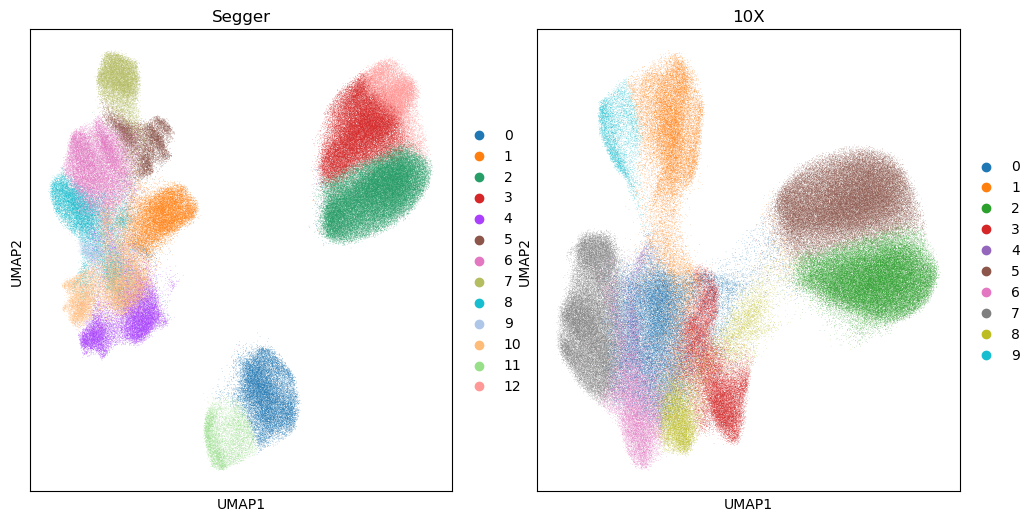

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sc.pl.umap(adata, color="leiden", ax=axs[0], show=False)
sc.pl.umap(adata_10x, color="leiden", ax=axs[1], show=False)
axs[0].set_title("Segger")
axs[1].set_title("10X")

## Visualize a crop

Pick a small spatial window around the data's center, plot the cell boundaries, and transcripts.

In [ ]:
# pick a crop
coords = adata.obsm["spatial"]
w = 100
xmin, ymin = 3600, 3500
xmax, ymax = xmin + w, ymin + w

# subset transcripts, add cluster
mask = tx["x"].between(xmin, xmax) & tx["y"].between(ymin, ymax)
tx_crop = tx.loc[mask].copy()
tx_crop["leiden"] = tx_crop["segger_cell_id"].map(adata.obs["leiden"]).astype(object)

# set unassigned transcripts
tx_crop.loc[tx_crop["leiden"].isna(), "leiden"] = "UNASSIGNED"
tx_crop.loc[~tx_crop["filtered"], "leiden"] = "UNASSIGNED"

# subset boundaries, add cluster
cell_ids = tx_crop["segger_cell_id"].dropna().unique()
boundaries_crop = boundaries.reindex(cell_ids).dropna(subset=["geometry"])
boundaries_crop["leiden"] = boundaries_crop.index.map(adata.obs["leiden"]).astype(object)
boundaries_crop.loc[boundaries_crop["leiden"].isna(), "leiden"] = "UNASSIGNED"

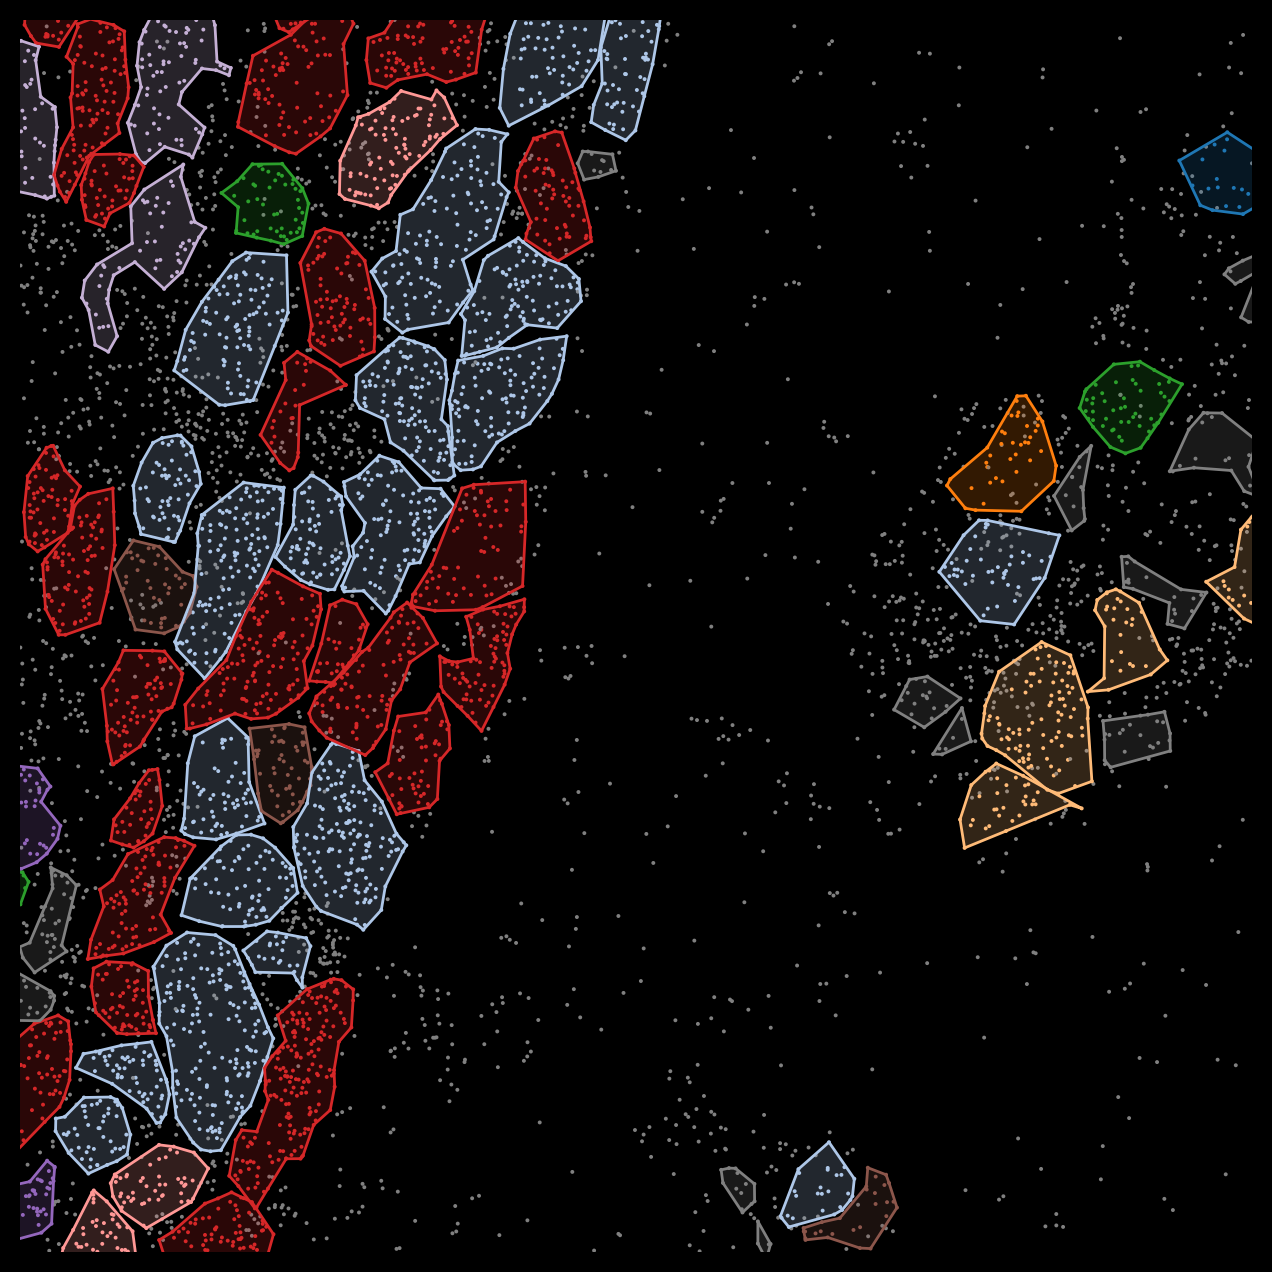

In [ ]:
# color scheme
cmap = dict(zip(adata.obs["leiden"].cat.categories, sns.color_palette("tab20")))
cmap["UNASSIGNED"] = [0.5, 0.5, 0.5]

# plot
fig, ax = plt.subplots(figsize=(8, 8), dpi=200, facecolor="black")
ax.set_facecolor("black")

# transcripts + boundaries
sns.scatterplot(
    tx_crop,
    x="x",
    y="y",
    hue="leiden",
    palette=cmap,
    s=2,
    linewidth=0,
    ax=ax,
)

face_colors = [mcolors.to_rgba(cmap[c], alpha=0.2) for c in boundaries_crop["leiden"]]
edge_colors = [mcolors.to_rgba(cmap[c], alpha=1.0) for c in boundaries_crop["leiden"]]

boundaries_crop.plot(
    ax=ax,
    facecolor=face_colors,
    edgecolor=edge_colors,
    linewidth=1,
)

ax.get_legend().remove()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")
plt.show()